# When partial Spark GPU acceleration stops helping

This output-complete notebook analyzes the same realistic PySpark ETL plan on
CPU and with the RAPIDS Accelerator. It then inserts one or two deliberate
Python CPU islands at different plan locations and varies how many columns
cross the boundary.

The central question is not whether Spark has GPU operators. It is whether
enough useful GPU work survives fallback and host/device transitions to beat
the equivalent complete CPU plan.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
scale = pd.read_csv(Path("results/scale_results.csv"))
fallback = pd.read_csv(Path("results/fallback_results.csv"))
len(scale), len(fallback), int(scale["trials"].sum() + fallback["trials"].sum())


(30, 48, 156)

## Experimental envelope

- Spark 3.5.8, RAPIDS Accelerator 26.06.1 for CUDA 13, Java 17.
- NVIDIA RTX PRO 4000 Blackwell SFF, 24 GB; Intel Core Ultra 9 285HX.
- One local Spark process, 16 worker threads, 32 shuffle partitions.
- Deterministic wide Zstandard Parquet fact data plus a 100,000-row dimension.
- Filter, broadcast join, projection, grouped aggregates, and final sort.
- Warm OS cache; one warmup and two measured actions per process; three
  independently started process replications per condition.
- Adaptive query execution disabled so physical-plan topology remains stable.
- Every accepted result matched a per-size CPU reference.

The CPU and GPU conditions load the same plugin in the same container. Only
`spark.rapids.sql.enabled` differs. For the main fallback matrix, RAPIDS
replacement of `ArrowEvalPythonExec` is disabled deliberately so each Pandas
UDF is a visible CPU island.


In [2]:
assert scale["correct"].all() and fallback["correct"].all()
assert len(scale) == 30 and len(fallback) == 48
assert int(scale["trials"].sum() + fallback["trials"].sum()) == 156
scale.groupby(["rows", "mode"])["replication"].nunique().unstack()


mode,cpu,gpu
rows,,
1000000,3,3
5000000,3,3
10000000,3,3
20000000,3,3
50000000,3,3


## 1. Native Spark/RAPIDS crossover


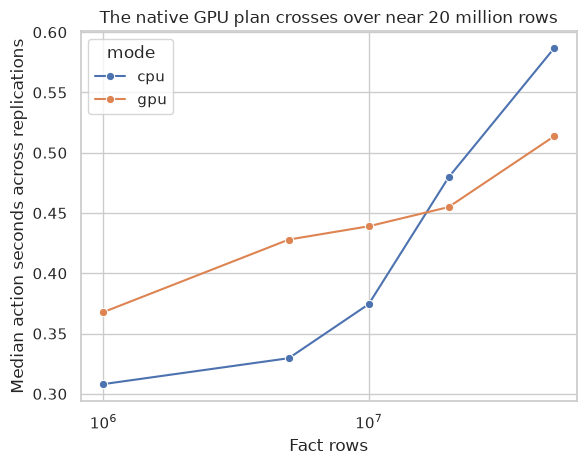

In [3]:
scale_agg = (
    scale.groupby(["rows", "mode"], as_index=False)
    .agg(median_seconds=("median_seconds", "median"),
         replication_min=("median_seconds", "min"),
         replication_max=("median_seconds", "max"))
)
chart = sns.lineplot(
    data=scale_agg, x="rows", y="median_seconds", hue="mode", marker="o"
)
chart.set_xscale("log")
chart.set_xlabel("Fact rows")
chart.set_ylabel("Median action seconds across replications")
chart.set_title("The native GPU plan crosses over near 20 million rows")
plt.show()


In [4]:
scale_table = scale_agg.pivot(index="rows", columns="mode", values="median_seconds")
scale_table["gpu_speedup"] = scale_table["cpu"] / scale_table["gpu"]
scale_table.round(3)


mode,cpu,gpu,gpu_speedup
rows,,,
1000000,0.308,0.368,0.838
5000000,0.330,0.428,0.770
10000000,0.374,0.439,0.853
20000000,0.480,0.455,1.054
50000000,0.587,0.514,1.142


CPU won through 10 million rows. The GPU reached practical parity at 20
million (1.05×) and won by 1.14× at 50 million in the scale matrix. Those are
measured points, not an exact universal crossover curve.


## 2. Moving one CPU island through the plan


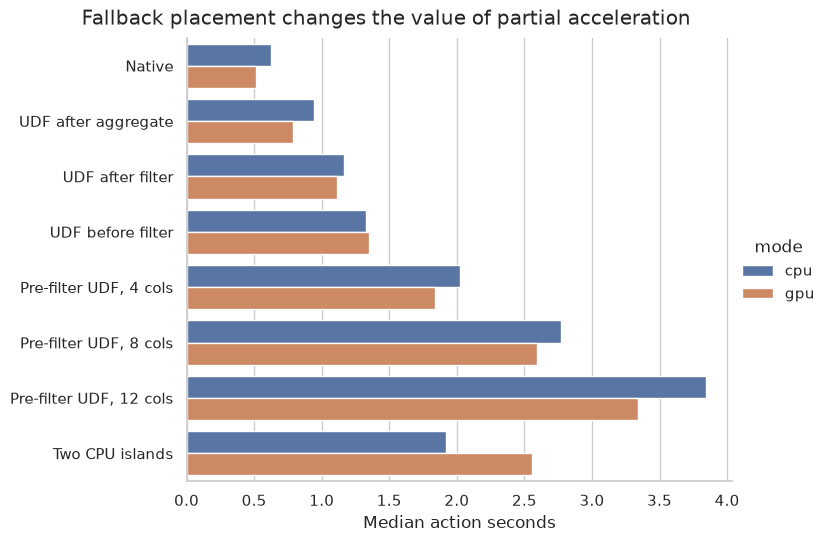

In [5]:
labels = {
    "native": "Native",
    "udf_post_aggregate": "UDF after aggregate",
    "udf_after_filter_1": "UDF after filter",
    "udf_before_filter_1": "UDF before filter",
    "udf_before_filter_4": "Pre-filter UDF, 4 cols",
    "udf_before_filter_8": "Pre-filter UDF, 8 cols",
    "udf_before_filter_12": "Pre-filter UDF, 12 cols",
    "udf_two_islands": "Two CPU islands",
}
order = list(labels)
agg = (
    fallback.groupby(["topology", "mode"], as_index=False)
    .agg(median_seconds=("median_seconds", "median"),
         replication_min=("median_seconds", "min"),
         replication_max=("median_seconds", "max"),
         transitions=("transitions", "median"))
)
agg["label"] = agg["topology"].map(labels)
agg["label"] = pd.Categorical(agg["label"], [labels[x] for x in order], ordered=True)
plot = sns.catplot(
    data=agg, y="label", x="median_seconds", hue="mode",
    kind="bar", height=5.3, aspect=1.5,
)
plot.set_axis_labels("Median action seconds", "")
plot.figure.suptitle("Fallback placement changes the value of partial acceleration", y=1.02)
plt.show()


In [6]:
comparison = agg.pivot(index="topology", columns="mode", values="median_seconds")
comparison["gpu_speedup"] = comparison["cpu"] / comparison["gpu"]
comparison["gpu_transitions"] = (
    agg[agg["mode"] == "gpu"].set_index("topology")["transitions"]
)
comparison.loc[order].rename(index=labels).round(3)


mode,cpu,gpu,gpu_speedup,gpu_transitions
topology,,,,
Native,0.626,0.511,1.225,1.0
UDF after aggregate,0.940,0.788,1.194,3.0
UDF after filter,1.166,1.113,1.047,3.0
UDF before filter,1.326,1.351,0.982,3.0
"Pre-filter UDF, 4 cols",2.022,1.836,1.102,3.0
"Pre-filter UDF, 8 cols",2.767,2.595,1.066,3.0
"Pre-filter UDF, 12 cols",3.847,3.343,1.151,3.0
Two CPU islands,1.921,2.559,0.750,5.0


The native 50-million-row GPU plan won by 1.22× in this randomized matrix.
With one CPU island after aggregation it still won by 1.19×; after the filter,
only 1.05×. Moving the same one-column UDF before the selective filter produced
practical parity (0.98×). Two separated CPU islands created five transition
nodes and made the hybrid plan 0.75× as fast as CPU—about 33% slower.


## 3. Width was not the main boundary


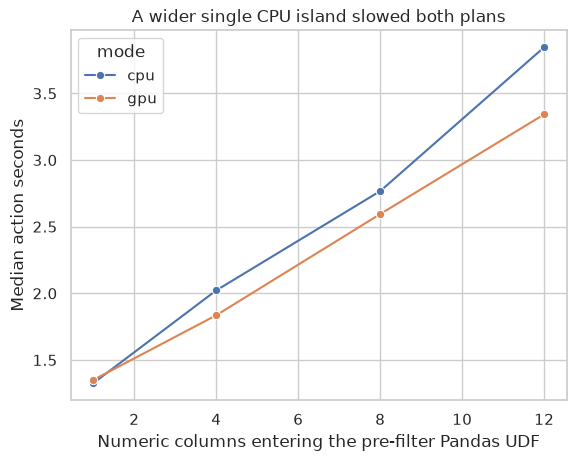

In [7]:
width_order = ["udf_before_filter_1", "udf_before_filter_4", "udf_before_filter_8", "udf_before_filter_12"]
width = fallback[fallback["topology"].isin(width_order)].copy()
width_agg = width.groupby(["udf_width", "mode"], as_index=False)["median_seconds"].median()
sns.lineplot(data=width_agg, x="udf_width", y="median_seconds", hue="mode", marker="o")
plt.xlabel("Numeric columns entering the pre-filter Pandas UDF")
plt.ylabel("Median action seconds")
plt.title("A wider single CPU island slowed both plans")
plt.show()


A single wider UDF slowed CPU and GPU modes together. Hybrid GPU execution
still beat the equivalent CPU plan at widths 4, 8, and 12. This means the
experiment does **not** support a simple rule such as “N fallback columns make
GPU execution uneconomic.” Placement and repeated boundaries mattered more
than width alone for this ETL shape.


## 4. The physical-plan anatomy


In [8]:
fallback[fallback["mode"] == "gpu"].groupby("topology")[[
    "gpu_plan_lines", "python_plan_lines", "transitions"
]].median().loc[order]


,gpu_plan_lines,python_plan_lines,transitions
topology,,,
native,18.0,0.0,1.0
udf_post_aggregate,21.0,1.0,3.0
udf_after_filter_1,19.0,1.0,3.0
udf_before_filter_1,22.0,1.0,3.0
udf_before_filter_4,22.0,1.0,3.0
udf_before_filter_8,22.0,1.0,3.0
udf_before_filter_12,22.0,1.0,3.0
udf_two_islands,25.0,2.0,5.0


Representative topology:

```text
One CPU island
GpuFileSourceScan → GpuColumnarToRow → ArrowEvalPython (CPU)
                  → GpuRowToColumnar → GpuFilter → GpuBroadcastHashJoin
                  → GpuHashAggregate → GpuSort → final host collection

Two CPU islands
Gpu scan → CPU Python → GPU filter/join → CPU Python
         → GPU aggregate/sort → final host collection
```

The final host collection appears even in the native GPU plan, so comparisons
use transition *topology*, not the presence of any transition at all.


## 5. Resource context


In [9]:
fallback.groupby(["topology", "mode"])[[
    "gpu_utilization_mean_percent", "gpu_energy_joules_estimate",
    "process_tree_cpu_cores_mean", "process_tree_rss_max_bytes"
]].median().round(2).loc[order]


gpu_utilization_mean_percent  \
topology             mode                                 
native               cpu                           0.00   
                     gpu                          10.83   
udf_post_aggregate   cpu                           0.00   
                     gpu                           3.81   
udf_after_filter_1   cpu                           0.00   
                     gpu                          22.21   
udf_before_filter_1  cpu                           0.00   
                     gpu                           1.89   
udf_before_filter_4  cpu                           0.00   
                     gpu                          29.46   
udf_before_filter_8  cpu                           0.00   
                     gpu                          25.24   
udf_before_filter_12 cpu                           0.00   
                     gpu                          31.00   
udf_two_islands      cpu                           0.00   
                     gpu                          14.90   

                           gpu_energy_joules_estimate  \
topology             mode                               
native               cpu                        10.31   
                     gpu                        13.67   
udf_post_aggregate   cpu                        15.55   
                     gpu                        22.27   
udf_after_filter_1   cpu                        19.13   
                     gpu                        32.79   
udf_before_filter_1  cpu                        21.30   
                     gpu                        34.96   
udf_before_filter_4  cpu                        32.98   
                     gpu                        56.15   
udf_before_filter_8  cpu                        45.55   
                     gpu                        80.85   
udf_before_filter_12 cpu                        61.90   
                     gpu                       102.78   
udf_two_islands      cpu                        31.15   
                     gpu                        65.72   

                           process_tree_cpu_cores_mean  \
topology             mode                                
native               cpu                         10.52   
                     gpu                          8.16   
udf_post_aggregate   cpu                         13.11   
                     gpu                         12.14   
udf_after_filter_1   cpu                         14.67   
                     gpu                         12.85   
udf_before_filter_1  cpu                         15.02   
                     gpu                         13.18   
udf_before_filter_4  cpu                         16.58   
                     gpu                         14.58   
udf_before_filter_8  cpu                         17.67   
                     gpu                         15.37   
udf_before_filter_12 cpu                         18.13   
                     gpu                         16.62   
udf_two_islands      cpu                         17.28   
                     gpu                         15.60   

                           process_tree_rss_max_bytes  
topology             mode                              
native               cpu                 1.577394e+10  
                     gpu                 1.072873e+10  
udf_post_aggregate   cpu                 2.093951e+10  
                     gpu                 1.499143e+10  
udf_after_filter_1   cpu                 2.091271e+10  
                     gpu                 1.622155e+10  
udf_before_filter_1  cpu                 2.139444e+10  
                     gpu                 1.722207e+10  
udf_before_filter_4  cpu                 3.054847e+10  
                     gpu                 1.929130e+10  
udf_before_filter_8  cpu                 4.136237e+10  
                     gpu                 2.023885e+10  
udf_before_filter_12 cpu                 4.929827e+10  
                     gpu                 2.555420e+1

GPU energy is a trapezoidal estimate from NVML power samples, not wall-socket
energy. NVML memory is whole-device allocation context: RAPIDS reserves most
of the device in an RMM pool, so it must not be interpreted as the query's live
working set. CPU and RSS telemetry includes the PySpark driver, JVM, and Python
worker descendants.


## What this evidence supports

1. **Inspect the executed plan, not the configuration.** A loaded accelerator
   and `spark.rapids.sql.enabled=true` do not prove end-to-end GPU execution.
2. **Find the native scale boundary first.** On this strong workstation CPU,
   the tested ETL needed roughly 20 million rows before GPU parity.
3. **Fallback after cardinality reduction can be cheap.** A CPU UDF over forty
   aggregate rows preserved most of the GPU advantage.
4. **Fallback before a selective operator is much more expensive.** The same
   one-column UDF before filtering erased the native advantage.
5. **Count boundaries, but also locate them.** Two separated CPU islands were
   decisively worse than CPU-only, while one wider island was not.
6. **Compare the hybrid plan with the equivalent CPU plan.** Wider UDFs slowed
   both modes; comparing every hybrid condition only with native CPU would
   confuse UDF cost with transition cost.

The practical rule is: use the qualification tools to find unsupported nodes,
then benchmark the executed mixed plan at representative scale. Push CPU-only
logic after filters and aggregations when possible, avoid repeated GPU↔CPU
islands, and keep a CPU-only escape hatch when the physical plan fragments.


## Excluded accelerated-bridge control

RAPIDS 26.06.1 enables partial acceleration of the Arrow backend around scalar
Pandas UDFs by default. A separate 50-million-row diagnostic restored that
setting. Seven initial cases completed, but one JVM terminated with a SIGSEGV
in `libcuda.so.1`; a retry completed the one-column case before the 12-column
case failed with the same signature. Those unstable timings are intentionally
excluded from the evidence above. The control config and retry-safe harness are
included under `full-benchmark/` for retesting on another driver/plugin stack.
